---
numbering:
  title: false
  headings: false
---

(sec:project_solubility_prediction)=

# Solubility prediction for organic molecules


## Background

Aqueous solubility is a key molecular property in pharmaceutical development, chemical formulation, and environmental assessment. A compound that dissolves poorly may be difficult to administer, test, manufacture, or remove from the environment. Experimental measurements are valuable but require laboratory time and material. This project investigates whether solubility can be estimated directly from molecular structure using machine learning.

The target is the experimentally measured logarithmic molar solubility

$$\log S = \log_{10}\left(S\;\right) [\mathrm{mol/L}].$$

Because the target is logarithmic, an absolute error of 0.5 logS units corresponds to an error of approximately $10^{0.5} \approx 3.16$ in the original solubility. 

The second interesting aspect is the influence of certain molecular descriptors on solubility. For example, the number of hydrogen bond donors and acceptors, the molecular weight, and the octanol-water partition coefficient (logP) are known to correlate with solubility. By analyzing the feature importance in machine learning models, it is possible to gain insights into which molecular properties are most predictive of solubility.

## Assets

Download the solubility dataset here: {download}`/assets/data/projects/ESOL_Dataset.csv`.


The Dataset used is the ESOL dataset, which contains 1128 organic molecules with experimentally measured aqueous solubility values. The dataset includes SMILES strings for each molecule, from which molecular descriptors can be derived.

The target column is the experimentally measured logarithmic molar solubility. The dataset has already been used to benchmark solubility prediction models.

ESOL-Dataset: https://pubs.acs.org/doi/suppl/10.1021/ci034243x/suppl_file/ci034243xsi20040112_053635.txt

*Reference:*
 Delaney, J. S. (2004). ESOL: Estimating Aqueous Solubility Directly from Molecular Structure. *Journal of Chemical Information and Computer Sciences*, 44(3), 1000–1005. https://doi.org/10.1021/ci034243x

## Implementation
The workflow is implemented in Python using the following imports:

In [ ]:
from __future__ import annotations
from pathlib import Path

import copy
import csv
import random
import statistics
import torch
from torch import nn
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from rdkit import Chem
from rdkit.Chem import Crippen, Descriptors, Lipinski, rdMolDescriptors

from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (make_scorer,mean_absolute_error,mean_squared_error)
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

from IPython.display import Image, display

### 1. Reading and cleaning the dataset
First the csv file is loaded and the dataset is inspected. The column ESOL predicted log(solubility:mol/L) is removed from the dataset. The cleaned dataset is saved as a new csv file.

In [28]:
from pathlib import Path

input_file = Path.cwd() / "../../assets/data/projects/ESOL_Dataset.csv"
output_file = Path.cwd() / "ESOL_Dataset_cleaned.csv"

column_to_remove = "ESOL predicted log(solubility:mol/L)"

with input_file.open("r", newline="") as infile, output_file.open("w", newline="") as outfile:
    reader = csv.DictReader(infile)
    fieldnames = [field for field in reader.fieldnames or [] if field != column_to_remove]

    writer = csv.DictWriter(outfile, fieldnames=fieldnames)
    writer.writeheader()

    for row in reader:
        row.pop(column_to_remove, None)
        writer.writerow(row)


### 2. Calculating molecular descriptors

Then the molecular descriptors are calculated for each compound in the dataset. The results are saved to a new csv file that contains the original data along with the calculated descriptors. 
The descriptors are later used to train three different machine learning models and a neural network.

In [29]:
PROJECT_DIR = Path.cwd()
DATA_PATH = PROJECT_DIR / "ESOL_Dataset_cleaned.csv"
OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

COLUMN_RENAMES = {
	"Compound ID": "compound_id",
	"measured log(solubility:mol/L)": "logS_measured",
	"SMILES": "smiles",
}

DESCRIPTOR_COLUMNS = [
	"molecular_weight",
	"mol_logp",
	"hbond_donors",
	"hbond_acceptors",
	"tpsa",
	"rotatable_bonds",
	"aromatic_rings",
	"heavy_atom_count",
	"fraction_csp3",
	"ring_count",
	"formal_charge",
	"max_abs_partial_charge",
	"molar_refractivity",
	"labute_asa",
	"bertz_complexity",
	"heteroatom_count",
	"aliphatic_rings"
]


def calculate_descriptors(smiles):
	mol = Chem.MolFromSmiles(smiles)
	if mol is None:
		return {
			"valid_smiles": False,
			"molecular_weight": None,
			"mol_logp": None,
			"hbond_donors": None,
			"hbond_acceptors": None,
			"tpsa": None,
			"rotatable_bonds": None,
			"aromatic_rings": None,
			"heavy_atom_count": None,
			"fraction_csp3": None,
			"ring_count": None,
			"formal_charge": None,
			"max_abs_partial_charge": None,
			"molar_refractivity": None,
			"labute_asa": None,
			"bertz_complexity": None,
			"heteroatom_count": None,
			"aliphatic_rings": None,
		}

	return {
		"valid_smiles": True,
		"molecular_weight": Descriptors.MolWt(mol),  
		"mol_logp": Crippen.MolLogP(mol),  
		"hbond_donors": Lipinski.NumHDonors(mol),  
		"hbond_acceptors": Lipinski.NumHAcceptors(mol),  
		"tpsa": rdMolDescriptors.CalcTPSA(mol),
		"rotatable_bonds": Lipinski.NumRotatableBonds(mol),  
		"aromatic_rings": rdMolDescriptors.CalcNumAromaticRings(mol),
		"heavy_atom_count": mol.GetNumHeavyAtoms(),
		"fraction_csp3": rdMolDescriptors.CalcFractionCSP3(mol),
		"ring_count": rdMolDescriptors.CalcNumRings(mol),
		"formal_charge": Chem.rdmolops.GetFormalCharge(mol),
		"max_abs_partial_charge": Descriptors.MaxAbsPartialCharge(mol), 
		"molar_refractivity": Crippen.MolMR(mol), 
		"labute_asa": rdMolDescriptors.CalcLabuteASA(mol),
		"bertz_complexity": Descriptors.BertzCT(mol), 
		"heteroatom_count": Lipinski.NumHeteroatoms(mol), 
		"aliphatic_rings": rdMolDescriptors.CalcNumAliphaticRings(mol)
	}

def main():
	with DATA_PATH.open("r", newline="") as infile:
		reader = csv.DictReader(infile)
		result_rows = []
		for row in reader:
			descriptor_row = calculate_descriptors(row["SMILES"])
			result_rows.append(
				{
					"compound_id": row["Compound ID"],
					"logS_measured": float(row["measured log(solubility:mol/L)"]),
					"smiles": row["SMILES"],
					**descriptor_row,
				}
			)
	output_path = OUTPUT_DIR / "esol_with_descriptors.csv"
	fieldnames = ["compound_id", "logS_measured", "smiles", "valid_smiles", *DESCRIPTOR_COLUMNS]
	with output_path.open("w", newline="") as outfile:
		writer = csv.DictWriter(outfile, fieldnames=fieldnames)
		writer.writeheader()
		writer.writerows(result_rows)
	print(f"Saved descriptor dataset to: {output_path}")


if __name__ == "__main__":
	main()

Saved descriptor dataset to: /Users/leaschussler/soluability_ml_nn_llm/outputs/esol_with_descriptors.csv


### 3. Training the machine learning models

Then the dataset that was built by adding the molecular descriptors, is split into training (80%) and test (20%) sets. The training set is used to fit three different machine learning models: linear regression, k-nearest neighbors (KNN), and random forest. Each model is evaluated on the test set using mean absolute error (MAE) and root mean squared error (RMSE).

$$\mathrm{MAE}=\frac{1}{n}\sum_{i=1}^{n}|y_i-\hat y_i|,$$
$$\mathrm{RMSE}=\sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat y_i)^2}.$$

RMSE penalises large errors more strongly, while MAE describes the typical absolute deviation. 

Lower values are better for both metrics.

In [41]:
PROJECT_DIR = Path.cwd()
DATA_PATH = PROJECT_DIR / "outputs" / "esol_with_descriptors.csv"
TARGET_COLUMN = "logS_measured"

def evaluate_model(name, y_true, y_pred):
	mae = mean_absolute_error(y_true, y_pred)
	return {
		"model": name,
		"MAE": mae,
		"RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
	}

def main():
	dataset = pd.read_csv(DATA_PATH)

	features = dataset[DESCRIPTOR_COLUMNS].apply(pd.to_numeric, errors="coerce")
	target = pd.to_numeric(dataset[TARGET_COLUMN], errors="coerce")

	rows = features.notna().all(axis=1) & target.notna()
	features = features.loc[rows].reset_index(drop=True)
	target = target.loc[rows].reset_index(drop=True)

	X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

	models = {
		"Linear regression": Pipeline(
			steps=[
				("imputer", SimpleImputer(strategy="median")),
				("scaler", StandardScaler()),
				("model", LinearRegression()),
			]
		),
		"k-nearest neighbors": Pipeline(
			steps=[
				("imputer", SimpleImputer(strategy="median")),
				("scaler", StandardScaler()),
				("model", KNeighborsRegressor(n_neighbors=5)),
			]
		),
		"Random forest": Pipeline(
            steps=[("imputer", SimpleImputer(strategy="median")),
				   ("model", RandomForestRegressor(n_estimators=500, random_state=42, min_samples_leaf=2))])}
	
	metrics = []
	for name, model in models.items():
		model.fit(X_train, y_train)
		y_pred = model.predict(X_test)
		metrics.append(evaluate_model(name, y_test, y_pred))

	metrics_df = pd.DataFrame(metrics)
	print("=== Model performance on test set ===")
	print(metrics_df.to_string(index=False))

if __name__ == "__main__":
	main()


=== Model performance on test set ===
              model      MAE     RMSE
  Linear regression 0.625380 0.780714
k-nearest neighbors 0.558339 0.728300
      Random forest 0.449740 0.605294


### 4. Training the neural network

Then a neural network is trained on the dataset. The neural network is implemented using PyTorch and is wrapped in a scikit-learn compatible interface. 

It is also evaluated on the a test set using MAE and RMSE.
Early stopping is used to prevent overfitting. The training process is monitored, and if the validation performance does not improve for a certain number of epochs, the training is stopped early.


70% of the dataset is used for training, 15% for validation, and 15% for testing. The random seed is set to 42 to ensure reproducibility. The neural network is trained for a maximum of 1000 epochs, with a patience of 30 epochs and a minimum delta of 0.002. The learning rate is set to 1e-3.

Patience is the number of epochs to wait for an improvement in validation loss before stopping the training. 

Minimum delta is the minimum change in validation loss to qualify as an improvement.

In [31]:
TRAIN_SIZE = 0.70
VAL_SIZE = 0.15
TEST_SIZE = 0.15
RANDOM_STATE = 42
NUM_EPOCHS = 1000
PATIENCE = 30
MIN_DELTA = 0.002
LEARNING_RATE = 1e-3

In [39]:
PROJECT_DIR = Path.cwd()
DATA_PATH = PROJECT_DIR / "outputs" / "esol_with_descriptors.csv"
TARGET_COLUMN = "logS_measured"
FEATURE_COLUMNS = DESCRIPTOR_COLUMNS


def set_seed(seed: int = RANDOM_STATE):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def load_esol_features():
    dataset = pd.read_csv(DATA_PATH)
    dataset[TARGET_COLUMN] = pd.to_numeric(dataset[TARGET_COLUMN], errors="coerce")
    features = dataset[FEATURE_COLUMNS].apply(pd.to_numeric, errors="coerce")

    valid_rows = dataset[TARGET_COLUMN].notna() & features.notna().all(axis=1)
    features = features.loc[valid_rows].reset_index(drop=True)
    target = dataset.loc[valid_rows, TARGET_COLUMN].reset_index(drop=True)

    return features, target


def build_model(input_dim: int):
    return nn.Sequential(
        nn.Linear(input_dim, 64),
        nn.ReLU(),
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Linear(32, 1),
    )


def rmse(predictions: torch.Tensor, targets: torch.Tensor):
    return torch.sqrt(nn.functional.mse_loss(predictions, targets)).item()


def mae(predictions: torch.Tensor, targets: torch.Tensor):
    return torch.mean(torch.abs(predictions - targets)).item()


def main():
    set_seed()

    features, target = load_esol_features()

    X_train, X_temp, y_train, y_temp = train_test_split(
        features,
        target,
        test_size=TEST_SIZE + VAL_SIZE,
        random_state=RANDOM_STATE,
    )
    relative_test_size = TEST_SIZE / (TEST_SIZE + VAL_SIZE)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp,
        y_temp,
        test_size=relative_test_size,
        random_state=RANDOM_STATE,
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
    X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

    y_train_tensor = torch.tensor(y_train.to_numpy(), dtype=torch.float32).view(-1, 1)
    y_val_tensor = torch.tensor(y_val.to_numpy(), dtype=torch.float32).view(-1, 1)
    y_test_tensor = torch.tensor(y_test.to_numpy(), dtype=torch.float32).view(-1, 1)

    model = build_model(X_train_tensor.shape[1])
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    best_val_rmse = float("inf")
    best_model_state: dict[str, torch.Tensor] | None = None
    best_epoch = 0
    epochs_without_improvement = 0

    for epoch in range(NUM_EPOCHS):
        model.train()
        optimizer.zero_grad()

        train_predictions = model(X_train_tensor)
        train_loss = loss_fn(train_predictions, y_train_tensor)

        train_loss.backward()
        optimizer.step()

        model.eval()

        with torch.no_grad():
            train_predictions_eval = model(X_train_tensor)
            val_predictions = model(X_val_tensor)

            train_rmse = rmse(train_predictions_eval, y_train_tensor)
            val_rmse = rmse(val_predictions, y_val_tensor)

        if val_rmse < best_val_rmse - MIN_DELTA:
            best_val_rmse = val_rmse
            best_model_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if (epoch + 1) % 30 == 0:
            print(
                f"Epoch {epoch + 1:4d} \n Train RMSE: {train_rmse:.3f} | Val RMSE: {val_rmse:.3f}")

        if epochs_without_improvement >= PATIENCE:
            print(f"Early stopping at epoch {epoch + 1}")
            break

    if best_model_state is None:
        raise RuntimeError("Training did not produce a best model state")

    model.load_state_dict(best_model_state)
    model.eval()

    with torch.no_grad():
        train_predictions = model(X_train_tensor)
        val_predictions = model(X_val_tensor)
        test_predictions = model(X_test_tensor)

        train_mae = mae(train_predictions, y_train_tensor)
        val_mae = mae(val_predictions, y_val_tensor)
        test_mae = mae(test_predictions, y_test_tensor)

        train_rmse = rmse(train_predictions, y_train_tensor)
        val_rmse = rmse(val_predictions, y_val_tensor)
        test_rmse = rmse(test_predictions, y_test_tensor)

    print(f"Trained on {len(features)} ESOL molecules using {len(FEATURE_COLUMNS)} descriptors.\n Best epoch: {best_epoch} \n Train MAE: {train_mae:.3f} | Train RMSE: {train_rmse:.3f} | Val MAE: {val_mae:.3f} | Val RMSE: {val_rmse:.3f} | Test MAE: {test_mae:.3f} | Test RMSE: {test_rmse:.3f}")

if __name__ == "__main__":
    main()

Epoch   30 
 Train RMSE: 2.511 | Val RMSE: 2.616
Epoch   60 
 Train RMSE: 1.318 | Val RMSE: 1.187
Epoch   90 
 Train RMSE: 1.066 | Val RMSE: 1.010
Epoch  120 
 Train RMSE: 0.946 | Val RMSE: 0.911
Epoch  150 
 Train RMSE: 0.869 | Val RMSE: 0.866
Epoch  180 
 Train RMSE: 0.818 | Val RMSE: 0.842
Epoch  210 
 Train RMSE: 0.780 | Val RMSE: 0.824
Epoch  240 
 Train RMSE: 0.750 | Val RMSE: 0.808
Epoch  270 
 Train RMSE: 0.725 | Val RMSE: 0.793
Epoch  300 
 Train RMSE: 0.701 | Val RMSE: 0.776
Epoch  330 
 Train RMSE: 0.678 | Val RMSE: 0.759
Epoch  360 
 Train RMSE: 0.658 | Val RMSE: 0.743
Epoch  390 
 Train RMSE: 0.640 | Val RMSE: 0.729
Epoch  420 
 Train RMSE: 0.624 | Val RMSE: 0.716
Epoch  450 
 Train RMSE: 0.608 | Val RMSE: 0.702
Epoch  480 
 Train RMSE: 0.592 | Val RMSE: 0.690
Epoch  510 
 Train RMSE: 0.577 | Val RMSE: 0.682
Epoch  540 
 Train RMSE: 0.563 | Val RMSE: 0.674
Epoch  570 
 Train RMSE: 0.549 | Val RMSE: 0.670
Epoch  600 
 Train RMSE: 0.536 | Val RMSE: 0.667
Epoch  630 
 Train R

### 5. Model evaluation via cross validation

The original model evaluations are not directly comparable because different data splits were used:

- The classical machine learning models used an **80% training / 20% test split**.
- The neural network used a **70% training / 15% validation / 15% test split**.

To compare the models more fairly, **5-fold cross validation** was used.



In cross validation, the dataset is divided into several equally sized parts, called *folds*. For 5-fold cross validation, the dataset is split into five folds. Each model is then trained and evaluated five times. In each run, four folds are used for training and one fold is used for testing. This is repeated until every fold has been used once as the test set.



![5-fold cross validation diagram](/assets/figures/projects/image-crossvalidation.png)


This approach has two advantages:

- Every molecule is used once for testing.
- The final performance is averaged across five different train-test splits.

As a result, the evaluation is more robust and less dependent on one random split of the dataset. This is especially important because the dataset is relatively small, so a single split may not represent the overall model performance well.

For the neural network, a validation set of **15% of the training data** was used during each cross-validation run to monitor training and apply early stopping.

In [33]:
N_SPLITS = 5
NN_VALIDATION_SIZE = 0.15

For the neural network, early stopping is used only to select the number of epochs. Refit preprocessing and a freshly initialised network on every sample in the outer training fold so all compared models see the same amount of fitting data.

In [34]:
def root_mean_squared_error(y_true, y_pred):
    return float(mean_squared_error(y_true, y_pred) ** 0.5)


class NeuralNetworkRegressor(RegressorMixin, BaseEstimator):
    def __init__(
        self,
        validation_size: float = NN_VALIDATION_SIZE,
        max_epochs: int = NUM_EPOCHS,
        patience: int = PATIENCE,
        min_delta: float = MIN_DELTA,
        learning_rate: float = LEARNING_RATE,
        random_state: int = RANDOM_STATE,
    ):
        self.validation_size = validation_size
        self.max_epochs = max_epochs
        self.patience = patience
        self.min_delta = min_delta
        self.learning_rate = learning_rate
        self.random_state = random_state

    def fit(self, X, y):
        set_seed(self.random_state)

        X_array = np.asarray(X, dtype=np.float32)
        y_array = np.asarray(y, dtype=np.float32).reshape(-1, 1)
        X_train, X_val, y_train, y_val = train_test_split(X_array, y_array, test_size=self.validation_size, random_state=self.random_state)

        selection_scaler = StandardScaler()
        X_train = selection_scaler.fit_transform(X_train)
        X_val = selection_scaler.transform(X_val)
            
        X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
        X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
        y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
        y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

        self.model_ = build_model(X_train_tensor.shape[1])
        loss_fn = nn.MSELoss()
        optimizer = torch.optim.Adam(
            self.model_.parameters(), lr=self.learning_rate)

        best_val_rmse = float("inf")
        best_model_state = None
        epochs_without_improvement = 0

        for epoch in range(self.max_epochs):
            self.model_.train()
            optimizer.zero_grad()
            loss = loss_fn(self.model_(X_train_tensor), y_train_tensor)
            loss.backward()
            optimizer.step()

            self.model_.eval()
            with torch.no_grad():
                val_rmse = rmse(self.model_(X_val_tensor), y_val_tensor)

            if val_rmse < best_val_rmse - self.min_delta:
                best_val_rmse = val_rmse
                best_model_state = copy.deepcopy(self.model_.state_dict())
                self.best_epoch_ = epoch + 1
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if epochs_without_improvement >= self.patience:
                break

        if best_model_state is None:
            raise RuntimeError("Neural-network training produced no model state")

        set_seed(self.random_state)
        self.scaler_ = StandardScaler()
        X_full = self.scaler_.fit_transform(X_array)
        X_full_tensor = torch.tensor(X_full, dtype=torch.float32)
        y_full_tensor = torch.tensor(y_array, dtype=torch.float32)

        self.model_ = build_model(X_full_tensor.shape[1])
        optimizer = torch.optim.Adam(
            self.model_.parameters(), lr=self.learning_rate
        )
        self.model_.train()
        for _ in range(self.best_epoch_):
            optimizer.zero_grad()
            loss = loss_fn(self.model_(X_full_tensor), y_full_tensor)
            loss.backward()
            optimizer.step()

        self.model_.eval()
        self.n_features_in_ = X_array.shape[1]
        return self

    def predict(self, X):
        X_scaled = self.scaler_.transform(np.asarray(X, dtype=np.float32))
        X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
        self.model_.eval()
        with torch.no_grad():
            return self.model_(X_tensor).cpu().numpy().ravel()


def build_models():
    return {
        "Linear regression": Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("model", LinearRegression()),
            ]
        ),
        "k-nearest neighbors": Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("model", KNeighborsRegressor(n_neighbors=5)),
            ]
        ),
        "Random forest": Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median")),
                (
                    "model",
                    RandomForestRegressor(
                        n_estimators=500,
                        random_state=RANDOM_STATE,
                        min_samples_leaf=2,
                    ),
                ),
            ]
        ),
        "Neural network": NeuralNetworkRegressor(),
    }


def main():
    features, target = load_esol_features()
    cross_validation = KFold(
        n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE
    )
    scoring = {
        "MAE": make_scorer(mean_absolute_error, greater_is_better=False),
        "RMSE": make_scorer(root_mean_squared_error, greater_is_better=False),
    }

    rows = []
    for name, model in build_models().items():
        print(f"Evaluating {name} ...")
        scores = cross_validate(
            model,
            features,
            target,
            cv=cross_validation,
            scoring=scoring,
            n_jobs=1,
        )
        mae_scores = -scores["test_MAE"]
        rmse_scores = -scores["test_RMSE"]
        rows.append(
            {
                "model": name,
                "MAE mean": mae_scores.mean(),
                "MAE std": mae_scores.std(ddof=1),
                "RMSE mean": rmse_scores.mean(),
                "RMSE std": rmse_scores.std(ddof=1),
            }
        )

    results = pd.DataFrame(rows).sort_values("RMSE mean")
    print(f"\n=== {N_SPLITS}-fold cross-validation ===")
    print(results.to_string(index=False, float_format=lambda value: f"{value:.3f}"))


if __name__ == "__main__":
    main()

Evaluating Linear regression ...
Evaluating k-nearest neighbors ...
Evaluating Random forest ...
Evaluating Neural network ...

=== 5-fold cross-validation ===
              model  MAE mean  MAE std  RMSE mean  RMSE std
      Random forest     0.476    0.040      0.667     0.058
     Neural network     0.493    0.031      0.675     0.066
k-nearest neighbors     0.555    0.025      0.752     0.047
  Linear regression     0.631    0.013      0.835     0.035


In [35]:
matplotlib.use("Agg")

ML_PLOT_PATH = PROJECT_DIR / "outputs" / "ml_learning_curves_17_descriptors.png"
ML_HISTORY_PATH = PROJECT_DIR / "outputs" / "ml_learning_curves_17_descriptors.csv"
NN_PLOT_PATH = PROJECT_DIR / "outputs" / "nn_training_history_17_descriptors.png"
NN_HISTORY_PATH = PROJECT_DIR / "outputs" / "nn_training_history_17_descriptors.csv"
TRAIN_FRACTIONS = np.linspace(0.1, 1.0, 10)


def rmse_from_arrays(y_true, y_pred) -> float:
    return float(mean_squared_error(y_true, y_pred) ** 0.5)


def build_ml_learning_history():
    features, target = load_esol_features()
    X_train, X_temp, y_train, y_temp = train_test_split(
        features,
        target,
        test_size=TEST_SIZE + VAL_SIZE,
        random_state=RANDOM_STATE,
    )
    relative_test_size = TEST_SIZE / (TEST_SIZE + VAL_SIZE)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp,
        y_temp,
        test_size=relative_test_size,
        random_state=RANDOM_STATE,
    )

    random_generator = np.random.default_rng(RANDOM_STATE)
    shuffled_positions = random_generator.permutation(len(X_train))
    models = {
        name: model
        for name, model in build_models().items()
        if name != "Neural network"
    }

    rows = []
    for name, base_model in models.items():
        print(f"Creating learning curve for {name} ...")
        for fraction in TRAIN_FRACTIONS:
            sample_count = max(10, round(len(X_train) * fraction))
            positions = shuffled_positions[:sample_count]
            X_subset = X_train.iloc[positions]
            y_subset = y_train.iloc[positions]

            model = clone(base_model)
            model.fit(X_subset, y_subset)

            rows.append(
                {
                    "model": name,
                    "training_samples": sample_count,
                    "training_fraction": fraction,
                    "train_rmse": rmse_from_arrays(y_subset, model.predict(X_subset)),
                    "validation_rmse": rmse_from_arrays(y_val, model.predict(X_val)),
                    "test_rmse": rmse_from_arrays(y_test, model.predict(X_test)),
                }
            )

    history = pd.DataFrame(rows)
    ML_HISTORY_PATH.parent.mkdir(exist_ok=True, parents=True)
    history.to_csv(ML_HISTORY_PATH, index=False)
    return history, list(models.keys())


def plot_ml_learning_curves(history: pd.DataFrame, model_names: list[str]):
    figure, axes = plt.subplots(1, len(model_names), figsize=(17, 5.5), sharey=True)
    axes = np.atleast_1d(axes)

    for axis, name in zip(axes, model_names):
        model_history = history.loc[history["model"] == name]
        axis.plot(
            model_history["training_samples"],
            model_history["train_rmse"],
            marker="o",
            label="Training",
            linewidth=2,
        )
        axis.plot(
            model_history["training_samples"],
            model_history["validation_rmse"],
            marker="o",
            label="Validation",
            linewidth=2,
        )
        axis.plot(
            model_history["training_samples"],
            model_history["test_rmse"],
            marker="o",
            label="Test (retrospective only)",
            linewidth=2,
            alpha=0.8,
        )
        axis.set_title(name)
        axis.set_xlabel("Number of training molecules")
        axis.grid(alpha=0.25)

    axes[0].set_ylabel("RMSE (logS)")
    axes[-1].legend(loc="best")
    figure.suptitle("Learning curves of the classical ML models", fontsize=16)
    figure.tight_layout()
    figure.savefig(ML_PLOT_PATH, dpi=300, bbox_inches="tight")
    plt.close(figure)

    final_results = history.loc[
        history.groupby("model")["training_samples"].idxmax(),
        ["model", "train_rmse", "validation_rmse", "test_rmse"],
    ]
    print("\n=== Results using all training molecules ===")
    print(final_results.to_string(index=False, float_format=lambda value: f"{value:.3f}"))
    print(f"\nPlot saved to: {ML_PLOT_PATH}")
    print(f"Values saved to: {ML_HISTORY_PATH}")


def build_nn_training_history():
    set_seed()
    features, target = load_esol_features()

    X_train, X_temp, y_train, y_temp = train_test_split(
        features,
        target,
        test_size=TEST_SIZE + VAL_SIZE,
        random_state=RANDOM_STATE,
    )
    relative_test_size = TEST_SIZE / (TEST_SIZE + VAL_SIZE)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp,
        y_temp,
        test_size=relative_test_size,
        random_state=RANDOM_STATE,
    )

    scaler = StandardScaler()
    X_train_tensor = torch.tensor(scaler.fit_transform(X_train), dtype=torch.float32)
    X_val_tensor = torch.tensor(scaler.transform(X_val), dtype=torch.float32)
    X_test_tensor = torch.tensor(scaler.transform(X_test), dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train.to_numpy(), dtype=torch.float32).view(-1, 1)
    y_val_tensor = torch.tensor(y_val.to_numpy(), dtype=torch.float32).view(-1, 1)
    y_test_tensor = torch.tensor(y_test.to_numpy(), dtype=torch.float32).view(-1, 1)

    model = build_model(X_train_tensor.shape[1])
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    history = []
    best_val_rmse = float("inf")
    best_model_state = None
    best_epoch = 0
    epochs_without_improvement = 0

    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()
        optimizer.zero_grad()
        loss = loss_fn(model(X_train_tensor), y_train_tensor)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            train_rmse = rmse(model(X_train_tensor), y_train_tensor)
            val_rmse = rmse(model(X_val_tensor), y_val_tensor)
            test_rmse = rmse(model(X_test_tensor), y_test_tensor)

        history.append(
            {
                "epoch": epoch,
                "train_rmse": train_rmse,
                "validation_rmse": val_rmse,
                "test_rmse": test_rmse,
            }
        )

        if val_rmse < best_val_rmse - MIN_DELTA:
            best_val_rmse = val_rmse
            best_model_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= PATIENCE:
            break

    if best_model_state is None:
        raise RuntimeError("Training did not produce a best model state")

    history_frame = pd.DataFrame(history)
    NN_HISTORY_PATH.parent.mkdir(exist_ok=True, parents=True)
    history_frame.to_csv(NN_HISTORY_PATH, index=False)

    model.load_state_dict(best_model_state)
    model.eval()
    with torch.no_grad():
        final_test_rmse = rmse(model(X_test_tensor), y_test_tensor)
        final_test_mae = mae(model(X_test_tensor), y_test_tensor)

    return history_frame, best_epoch, final_test_rmse, final_test_mae


def plot_nn_training_history(history_frame: pd.DataFrame, best_epoch: int):
    figure, axis = plt.subplots(figsize=(10, 6))
    axis.plot(
        history_frame["epoch"],
        history_frame["train_rmse"],
        label="Training",
        linewidth=2.2,
    )
    axis.plot(
        history_frame["epoch"],
        history_frame["validation_rmse"],
        label="Validation",
        linewidth=2.2,
    )
    axis.plot(
        history_frame["epoch"],
        history_frame["test_rmse"],
        label="Test (retrospective only)",
        linewidth=2.0,
        alpha=0.8,
    )
    axis.axvline(
        best_epoch,
        color="black",
        linestyle="--",
        linewidth=1.5,
        label=f"Best epoch: {best_epoch}",
    )
    axis.set_title("Neural network training history")
    axis.set_xlabel("Epoch")
    axis.set_ylabel("RMSE (logS)")
    axis.grid(alpha=0.25)
    axis.legend()
    figure.tight_layout()
    figure.savefig(NN_PLOT_PATH, dpi=300, bbox_inches="tight")
    plt.close(figure)

    print(f"Plot saved to: {NN_PLOT_PATH}")
    print(f"Values saved to: {NN_HISTORY_PATH}")


def main():
    ml_history, model_names = build_ml_learning_history()
    plot_ml_learning_curves(ml_history, model_names)

    nn_history, best_epoch, final_test_rmse, final_test_mae = build_nn_training_history()
    plot_nn_training_history(nn_history, best_epoch)

    print("\n=== Neural network summary ===")
    print(f"Epochs recorded: {len(nn_history)}")
    print(f"Best epoch selected by validation RMSE: {best_epoch}")
    print(f"Test RMSE at best epoch: {final_test_rmse:.3f}")
    print(f"Test MAE at best epoch: {final_test_mae:.3f}")


main()

Creating learning curve for Linear regression ...
Creating learning curve for k-nearest neighbors ...
Creating learning curve for Random forest ...

=== Results using all training molecules ===
              model  train_rmse  validation_rmse  test_rmse
  Linear regression       0.825            0.814      0.780
      Random forest       0.330            0.730      0.576
k-nearest neighbors       0.626            0.776      0.673

Plot saved to: /Users/leaschussler/soluability_ml_nn_llm/outputs/ml_learning_curves_17_descriptors.png
Values saved to: /Users/leaschussler/soluability_ml_nn_llm/outputs/ml_learning_curves_17_descriptors.csv
Plot saved to: /Users/leaschussler/soluability_ml_nn_llm/outputs/nn_training_history_17_descriptors.png
Values saved to: /Users/leaschussler/soluability_ml_nn_llm/outputs/nn_training_history_17_descriptors.csv

=== Neural network summary ===
Epochs recorded: 685
Best epoch selected by validation RMSE: 655
Test RMSE at best epoch: 0.615
Test MAE at best ep

### 6. Descriptor Analysis

Finally, the importance of the molecular descriptors used in the models is analyzed. This helps understand which molecular properties are most predictive of solubility and can provide insights into the underlying chemistry. 

#### Permutation importance

Prediction performance alone does not show whether a model uses chemically meaningful information. Therefore, permutation importance was used to estimate how strongly each molecular descriptor contributed to the predictions of the nonlinear models.

For this analysis, each model was refitted on every outer cross-validation training fold. Then, one descriptor at a time was randomly shuffled in the corresponding held-out test fold, while all other descriptors remained unchanged. The model was evaluated again after shuffling.

If the test MAE increased strongly after shuffling a descriptor, this means that the descriptor contained important predictive information for the model. The importance value was reported as the **mean increase in MAE** across the five folds, together with the corresponding standard deviation.

A larger permutation importance value therefore indicates that the descriptor is more important for the model's predictions. However, permutation importance only shows how relevant a descriptor is for prediction accuracy. It does **not** show whether higher descriptor values increase or decrease predicted solubility.

In [36]:
explanation_features, explanation_target = load_esol_features()
explanation_cv = KFold(
    n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE
)
explanation_models = {
    name: model
    for name, model in build_models().items()
    if name in {"Random forest", "Neural network"}
}
importance_by_model = {name: [] for name in explanation_models}

for fold, (train_index, test_index) in enumerate(
    explanation_cv.split(explanation_features), start=1
):
    X_train_fold = explanation_features.iloc[train_index]
    X_test_fold = explanation_features.iloc[test_index]
    y_train_fold = explanation_target.iloc[train_index]
    y_test_fold = explanation_target.iloc[test_index]

    for model_number, (name, base_model) in enumerate(explanation_models.items()):
        fitted_model = clone(base_model).fit(X_train_fold, y_train_fold)
        result = permutation_importance(
            fitted_model,
            X_test_fold,
            y_test_fold,
            scoring="neg_mean_absolute_error",
            n_repeats=20,
            random_state=RANDOM_STATE + 100 * model_number + fold,
            n_jobs=1,
        )
        importance_by_model[name].append(
            pd.Series(
                result.importances_mean,
                index=explanation_features.columns,
                name=f"Fold {fold}",
            )
        )

importance_tables = {}
for name, fold_results in importance_by_model.items():
    fold_table = pd.concat(fold_results, axis=1)
    importance_tables[name] = (
        pd.DataFrame({
            "Mean MAE increase": fold_table.mean(axis=1),
            "Fold SD": fold_table.std(axis=1, ddof=1),
        })
        .sort_values("Mean MAE increase", ascending=False)
    )
    print(f"{name}: held-out permutation importance")
    display(importance_tables[name].round(3))

Random forest: held-out permutation importance


,Mean MAE increase,Fold SD
mol_logp,1.311,0.023
bertz_complexity,0.118,0.033
molar_refractivity,0.105,0.022
max_abs_partial_charge,0.091,0.015
heteroatom_count,0.035,0.004
tpsa,0.033,0.005
molecular_weight,0.029,0.007
fraction_csp3,0.015,0.006
labute_asa,0.011,0.003
rotatable_bonds,0.008,0.002


Neural network: held-out permutation importance


,Mean MAE increase,Fold SD
mol_logp,0.925,0.164
molar_refractivity,0.408,0.112
heavy_atom_count,0.255,0.050
max_abs_partial_charge,0.250,0.043
hbond_acceptors,0.115,0.044
heteroatom_count,0.111,0.042
molecular_weight,0.095,0.045
tpsa,0.087,0.031
aliphatic_rings,0.081,0.037
fraction_csp3,0.076,0.012


#### Numerical partial-dependence summary

Permutation importance shows how strongly a descriptor affects prediction accuracy, but it does not show the **direction** of the effect. Therefore, a numerical partial-dependence summary was used.

For each selected descriptor, all molecules were evaluated twice:

1. with the descriptor set to its **5th-percentile value**
2. with the descriptor set to its **95th-percentile value**

The difference between the two mean predictions was then calculated.

- A **positive value** means that the model predicts higher logS at the higher descriptor value.
- A **negative value** means that the model predicts lower logS at the higher descriptor value.

This analysis describes the behaviour of the trained model. It should not be interpreted as direct chemical causality, because descriptors can be correlated and changing one descriptor alone may create unrealistic descriptor combinations.

In [37]:
direction_descriptors = [
    "mol_logp",
    "molecular_weight",
    "tpsa",
    "hbond_donors",
    "hbond_acceptors",
    "max_abs_partial_charge",
]
direction_features = explanation_features.astype(float)
direction_rows = []

for model_name, base_model in explanation_models.items():
    fitted_model = clone(base_model).fit(direction_features, explanation_target)
    for descriptor in direction_descriptors:
        low_value, high_value = direction_features[descriptor].quantile([0.05, 0.95])
        low_features = direction_features.copy()
        high_features = direction_features.copy()
        low_features[descriptor] = low_value
        high_features[descriptor] = high_value
        mean_low_prediction = fitted_model.predict(low_features).mean()
        mean_high_prediction = fitted_model.predict(high_features).mean()
        direction_rows.append({
            "Model": model_name,
            "Descriptor": descriptor,
            "5th percentile": low_value,
            "95th percentile": high_value,
            "Predicted logS change": mean_high_prediction - mean_low_prediction,
        })

direction_table = pd.DataFrame(direction_rows)
display(direction_table.round(3))
print(
    "Unique formal-charge values:",
    sorted(explanation_features["formal_charge"].unique())
)

,Model,Descriptor,5th percentile,95th percentile,Predicted logS change
0,Random forest,mol_logp,-0.311,5.737,-5.421
1,Random forest,molecular_weight,74.123,389.657,-0.145
2,Random forest,tpsa,0.000,100.871,-0.077
3,Random forest,hbond_donors,0.000,2.000,-0.008
4,Random forest,hbond_acceptors,0.000,6.000,0.039
5,Random forest,max_abs_partial_charge,0.062,0.507,0.561
6,Neural network,mol_logp,-0.311,5.737,-4.034
7,Neural network,molecular_weight,74.123,389.657,0.439
8,Neural network,tpsa,0.000,100.871,-0.096
9,Neural network,hbond_donors,0.000,2.000,-0.199


Unique formal-charge values: [0]


## Results

### Results of the classical machine learning models and the neural network

The classical machine learning models showed the expected learning-curve pattern: performance improved as more training molecules were added, with random forest giving the strongest overall results and the smallest test RMSE among the classical models. k-nearest neighbors improved steadily but stayed behind random forest, while linear regression plateaued earlier and remained the least accurate of the three.

The neural network also benefited from longer training. Its validation RMSE reached a minimum at the selected best epoch, and the final test performance was RMSE 0.615 and MAE 0.453. Overall, the plots show that the descriptor-based models can predict solubility reasonably well, but the random forest and neural network capture the nonlinear structure in the data better than linear regression.

Even though the random forest has the best performance it shows signs of overfitting, as the training RMSE is much lower than the test RMSE. This indicates that the model has learned the training data too well and may not generalize well to unseen data.

The neural network is more complex than the classical models, but it does not overfit the data. The early stopping mechanism helps to prevent overfitting by stopping the training process when the validation performance stops improving. This ensures that the model generalizes well to unseen data.

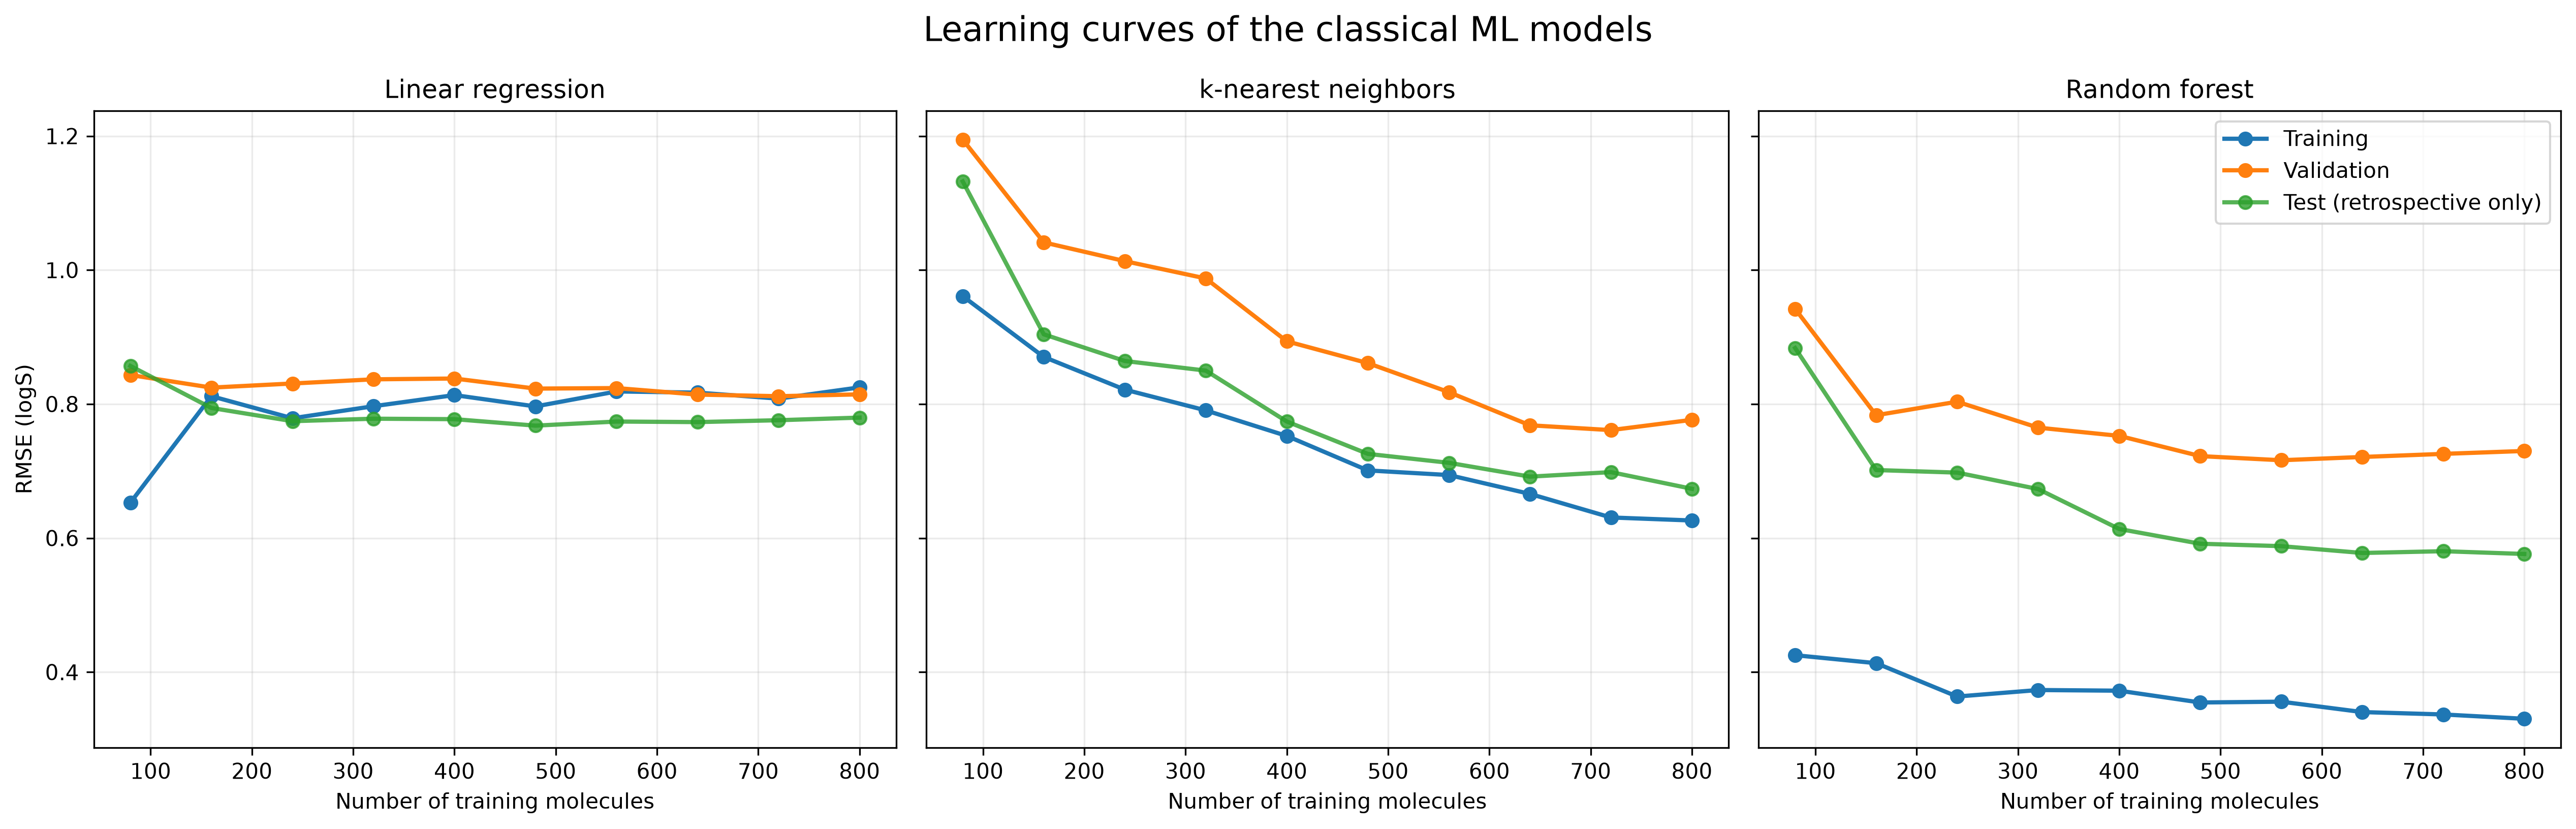

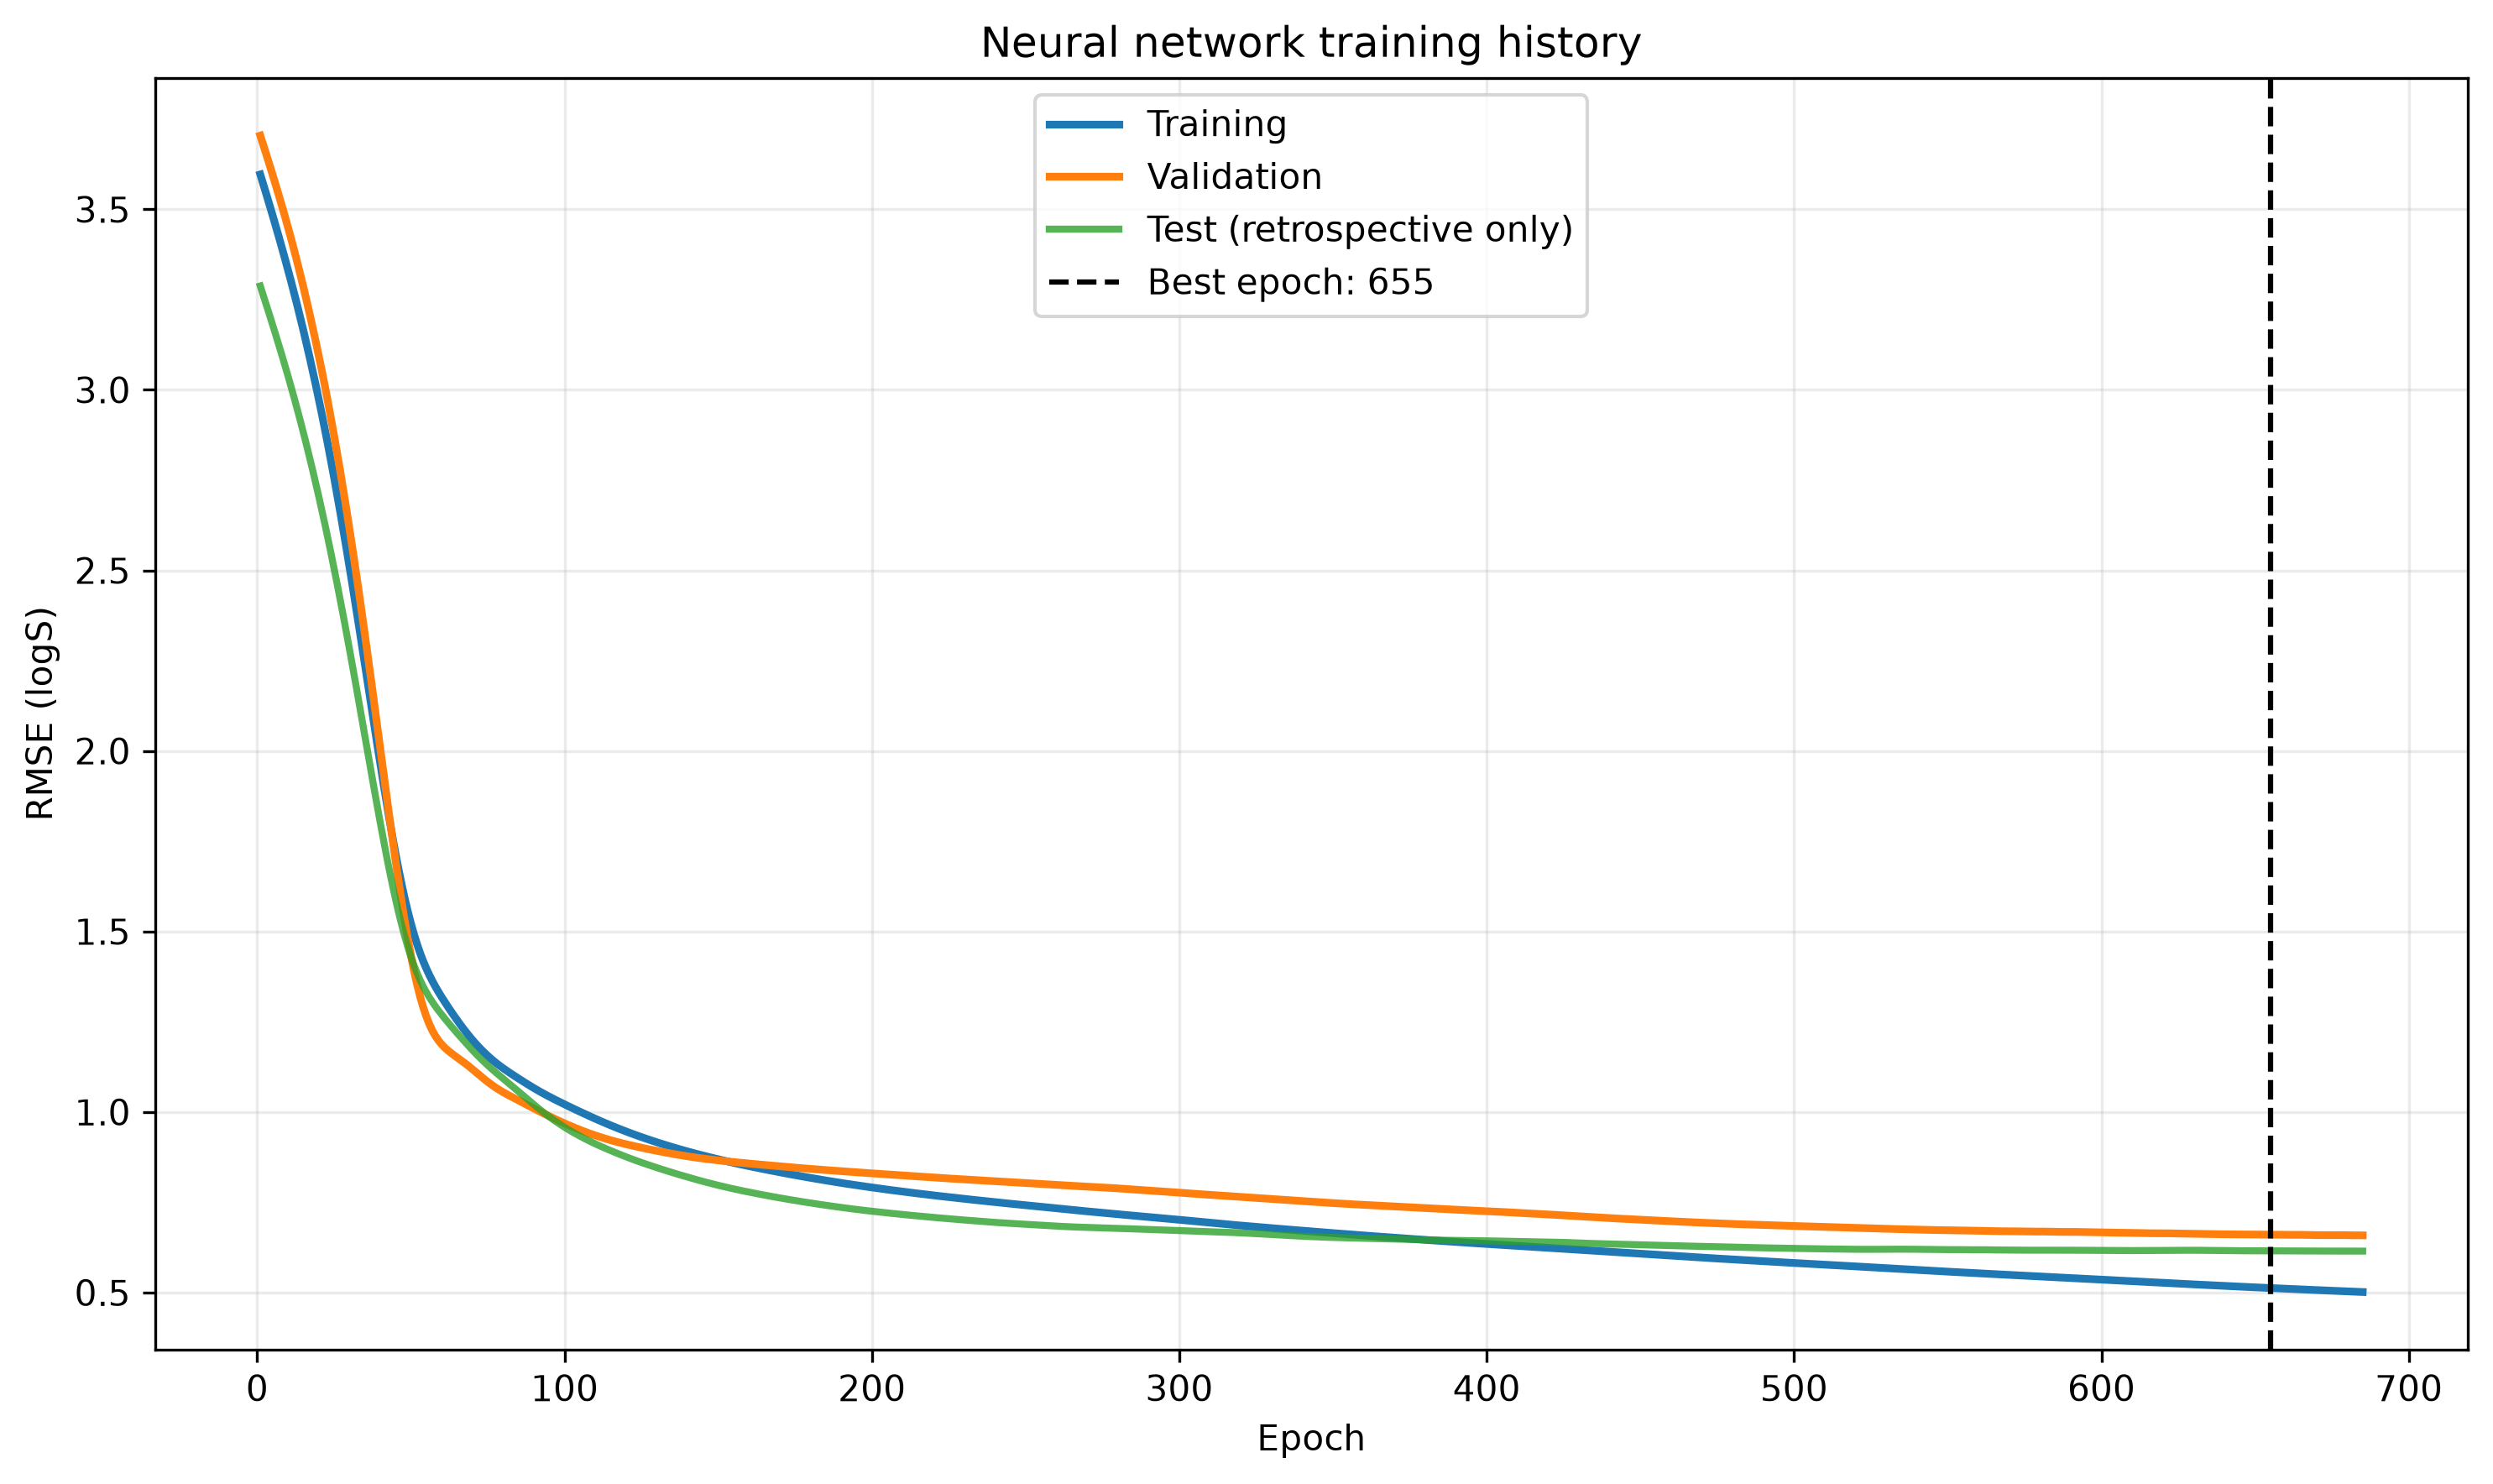

In [10]:
display(Image(filename=str(ML_PLOT_PATH)))
display(Image(filename=str(NN_PLOT_PATH)))

### Results of the descriptor analysis

Both models identify **lipophilicity, represented by MolLogP, as the most important descriptor for predicted solubility**. The descriptor importances should be interpreted within each model, because many descriptors are correlated.

#### Dominant effect: MolLogP

- **Random forest:** Permuting MolLogP increases held-out MAE by **1.311 logS units**. Increasing MolLogP from the 5th to the 95th percentile lowers mean predicted logS by **5.421 units**.
- **Neural network:** Permuting MolLogP increases held-out MAE by **0.925 logS units**. Across the same range, mean predicted logS decreases by **4.034 units**.

This is chemically plausible, because higher MolLogP means stronger lipophilicity and therefore less favourable transfer into water.

#### Secondary effects

The remaining descriptors have smaller effects. The random forest mainly uses Bertz complexity, molar refractivity, and maximum absolute partial charge, whereas the neural network distributes importance more broadly across size, polarity, hydrogen-bonding, and charge-related descriptors.

Both models predict higher logS with increasing maximum absolute partial charge, which is reasonable because stronger local electrostatic interactions can support hydration. Size-related descriptors such as molecular weight, surface area, heavy-atom count, refractivity, and complexity may also reflect larger hydrophobic surfaces or stronger solid-state interactions.



### Implications and limitations
#### Implications and limitations of the models

The descriptor-based models are useful for **screening, ranking, and prioritising compounds**, but they should not replace experimental solubility measurements. Since the target is logarithmic, even an error of 0.5 logS units corresponds to an approximately $10^{0.5} \approx 3.16$-fold error in original solubility.

The results are therefore most reliable for relative comparisons rather than exact solubility prediction. Main limitations are the modest dataset size and the restriction to precomputed molecular descriptors.

#### Implications and limitations of the descriptors

Descriptor effects should be interpreted cautiously because many descriptors are correlated. Unexpected trends, such as the slightly negative TPSA effect or isolated neural-network effects for molecular weight and hydrogen-bond donors, are best understood as **conditional model behaviour**, not direct chemical mechanisms.

Key limitations are:

- Descriptor importances are not independent because of correlations.
- The 17 global descriptors do not allow atom-, fragment-, or functional-group-level explanations.

More detailed explanations would require fingerprints, fragment features, or atom-level molecular representations with suitable attribution methods.

## Further Questions

A natural extension would be to compare these descriptor-based models with models trained on molecular fingerprints or graph neural networks, which could capture structure more directly. It would also be useful to test whether additional descriptor engineering, feature selection or hyperparameter tuning improves generalization.